
# Задание 1

Нейрон МакКалока-Питтса

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def McCuloh_Pitts_neuron(x = None, w = None, bias = 0): #x - входные сигналы, w - множители, bias - смещение
 s = np.dot(w, x.T )+ bias # Взвешенная сумма
 y = np.sign(s) # пороговая Функция активации
 return y

In [11]:
x = np.array([1,0])
w = np.array([1,-1])
y_out = McCuloh_Pitts_neuron(x = x, w = w, bias = 0.3)
print('ответ нейрона при X = [1, 0], W = [1, -1]',y_out)
print()

x = np.random.random((10,2)) #10 случайных точек в диапазоне от 0 до 1
w = np.array([1,-1]) #коэффициент при X1 положительный, при X2 — отрицательный
y_out1 = McCuloh_Pitts_neuron(x = x, w = w, bias = 0.3)
print('ответ нейрона на матрице',y_out1)
print('=> нейрон разделяет плоскость прямой линией, X2 = X1 + 0.3')


ответ нейрона при X = [1, 0], W = [1, -1] 1.0

ответ нейрона на матрице [ 1. -1.  1.  1.  1. -1.  1. -1. -1.  1.]
=> нейрон разделяет плоскость прямой линией, X2 = X1 + 0.3


Линейный нейрон

In [12]:
def linear_neuron(x = None, w = None, bias = 0):
 s = np.dot(w, x.T )+ bias
 y = s # Нет функции активации
 return y

In [13]:
#Запустим нейрон на множестве примеров в х
x = np.random.random((10,2))
w = np.array([1,-1])
y_out1 = linear_neuron(x = x, w = w, bias = 0.3)
print('ответ нейрона',y_out1)
print('=> Нейрон вычисляет скалярное произведение входов на веса плюс смещение')

ответ нейрона [ 1.00949016  0.00274908 -0.33196958  0.48609716  0.61507656  0.42991298
  0.43492346  0.23276027  0.58428148 -0.37804978]
=> Нейрон вычисляет скалярное произведение входов на веса плюс смещение


Сигмоидный нейрон

In [14]:
def sigmoid_neuron(x = None, w = None, bias=0):
  s = np.dot(w, x.T )+ bias
  y = 1 / (1 + np.exp(-s)) #сигмоидальная функция активации, которая "сжимает" выход в диапазон (0, 1)
  return y

In [15]:
x = np.linspace(-10,10.1,20).reshape((20,1))
w = np.array([0.9]).reshape((1,1))
bias =0.3

y_out2 = sigmoid_neuron(x = x, w = w, bias = 0.3)
print('ответ нейрона',y_out2)

ответ нейрона [[1.66558065e-04 4.31464081e-04 1.11722503e-03 2.88977058e-03
  7.45358282e-03 1.90870489e-02 4.79997991e-02 1.15549948e-01
  2.52908880e-01 4.67283653e-01 6.94459739e-01 8.54849947e-01
  9.38501009e-01 9.75334342e-01 9.90334440e-01 9.96247521e-01
  9.98548470e-01 9.99439314e-01 9.99783541e-01 9.99916452e-01]]


Тангенциальный


In [16]:
def sigmoidt_neuron(x = None, w = None, bias=0):
  s = np.dot(w, x.T )+ bias
  y = 2 / (1 + np.exp(-s))-1 #Вариант сигмоиды с выходом в диапазоне (-1, 1)
  return y

In [17]:
x = np.linspace(-10,10.1,20).reshape((20,1))
w = np.array([0.9]).reshape((1,1))
bias =0.3

y_out2 = sigmoid_neuron(x = x, w = w, bias = 0.3)
print('ответ нейрона',y_out2)

ответ нейрона [[1.66558065e-04 4.31464081e-04 1.11722503e-03 2.88977058e-03
  7.45358282e-03 1.90870489e-02 4.79997991e-02 1.15549948e-01
  2.52908880e-01 4.67283653e-01 6.94459739e-01 8.54849947e-01
  9.38501009e-01 9.75334342e-01 9.90334440e-01 9.96247521e-01
  9.98548470e-01 9.99439314e-01 9.99783541e-01 9.99916452e-01]]


Сигмоидный нейрон с параметром λ

In [18]:
def sigmoidt_complex_neuron(x=None, w=None, bias=0, lymb=1): #Модификация sigmoidt_neuron с параметром крутизны
    s = np.dot(w, x.T) + bias
    y = 2 / (1 + np.exp(-s / lymb)) - 1
    return y

Запустим все нейроны на множестве примеров (линейно равномерно распределены в интервале от -10
до 10)

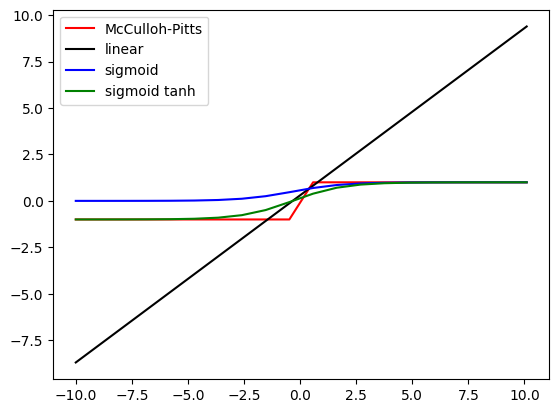

In [19]:
# Визуализация всех нейронов на одном графике
x = np.linspace(-10, 10.1, 20).reshape((20, 1))
w = np.array([0.9]).reshape((1, 1))
bias = 0.3

y_out1 = McCuloh_Pitts_neuron(x=x, w=w, bias=0.3)  # sign
y_out2 = sigmoid_neuron(x=x, w=w, bias=0.3)         # sigmoid (0,1)
y_out3 = sigmoidt_neuron(x=x, w=w, bias=0.3)        # tanh (-1,1)
y_out4 = linear_neuron(x=x, w=w, bias=0.3)          # linear

plt.plot(x[:,0].T, y_out1[0,:], 'r', label='McCulloh-Pitts')
plt.plot(x[:,0].T, y_out4[0,:], 'k', label='linear')
plt.plot(x[:,0].T, y_out2[0,:], 'b', label='sigmoid')
plt.plot(x[:,0].T, y_out3[0,:], 'g', label='sigmoid tanh')

plt.legend()
plt.show()

Сравнительный анализ

Графики производных активационных функций...


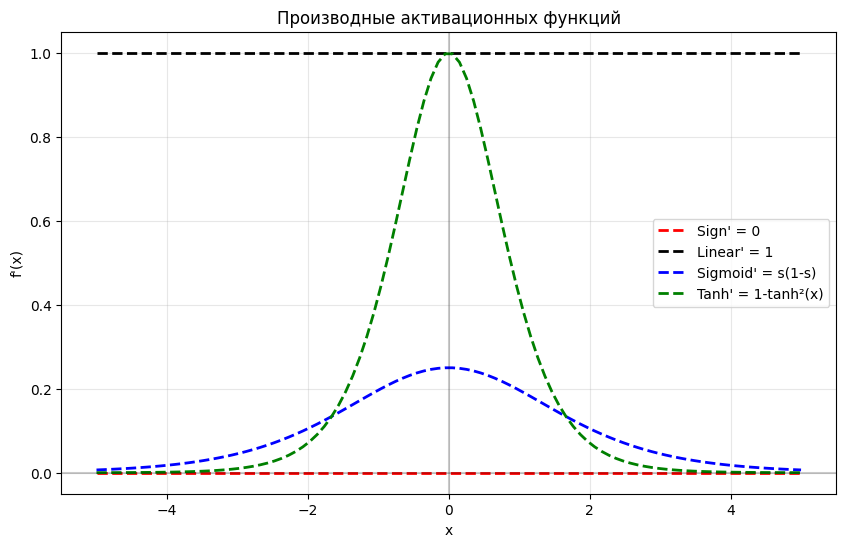


Сравнительный анализ:
- Sign: производная = 0 (кроме точки 0), недифференцируема
- Linear: производная = 1 (константа), простая
- Sigmoid: производная = s(1-s), максимум 0.25, гладкая
- Tanh: производная = 1-tanh²(x), максимум 1, симметричная



In [26]:
print("Графики производных активационных функций...")

def derivative_sigmoid(x):
    s = 1 / (1 + np.exp(-x))
    return s * (1 - s)

def derivative_tanh(x):
    return 1 - np.tanh(x)**2

x = np.linspace(-5, 5, 100)

plt.figure(figsize=(10, 6))
plt.plot(x, np.zeros_like(x), 'r--', label="Sign' = 0", linewidth=2)
plt.plot(x, np.ones_like(x), 'k--', label="Linear' = 1", linewidth=2)
plt.plot(x, derivative_sigmoid(x), 'b--', label="Sigmoid' = s(1-s)", linewidth=2)
plt.plot(x, derivative_tanh(x), 'g--', label="Tanh' = 1-tanh²(x)", linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.2)
plt.legend()
plt.title('Производные активационных функций')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.grid(True, alpha=0.3)
plt.show()
print()

print("Сравнительный анализ:")
print("- Sign: производная = 0 (кроме точки 0), недифференцируема")
print("- Linear: производная = 1 (константа), простая")
print("- Sigmoid: производная = s(1-s), максимум 0.25, гладкая")
print("- Tanh: производная = 1-tanh²(x), максимум 1, симметричная")
print()

# Задание 2. Создание модели двухмерного нейрона

Строим поле координат 10х10

In [20]:
x1 = np.array([np.linspace(-10,11,10).reshape((10,1))]*10).reshape((10,10))
x2 = x1.T
x2=x2.reshape((100,1))
x1=x1.reshape((100,1))
x = np.hstack([x1,x2])

print("Размерность данных:", x.shape)

Размерность данных: (100, 2)


Строим поверхность двухмерного нейрона (чем желтее, тем ближе к 1, чем синее, тем ближе к -1)


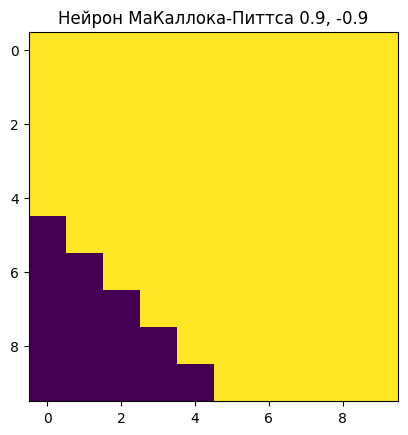

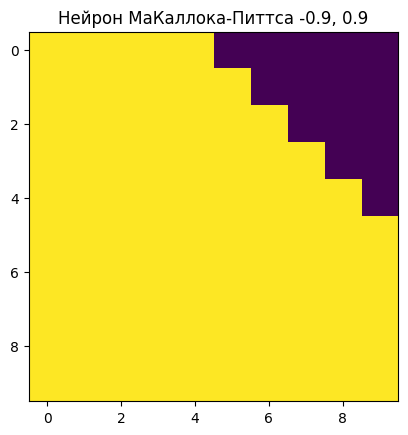

In [21]:
#Визуализация нейрона МакКаллока-Питтса
w = np.array([0.9, -0.9]).reshape((1, 2))
y_out_21 = McCuloh_Pitts_neuron(x=x, w=w, bias=10)
y_out_21 = y_out_21.reshape((10,10))

plt.imshow((y_out_21 ))
plt.title(f'Нейрон МаКаллока-Питтса 0.9, -0.9')
plt.show()

w = np.array([-0.9, 0.9]).reshape((1, 2))
y_out_21 = McCuloh_Pitts_neuron(x=x, w=w, bias=10)
y_out_21 = y_out_21.reshape((10,10))

plt.imshow((y_out_21 ))
plt.title(f'Нейрон МаКаллока-Питтса -0.9, 0.9')
plt.show()

Сигмоидный нейрон

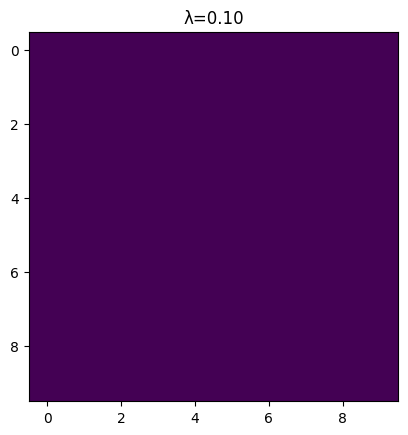

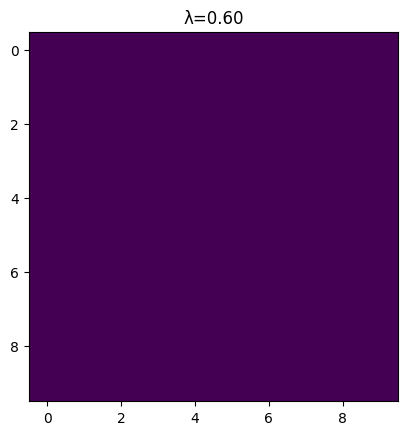

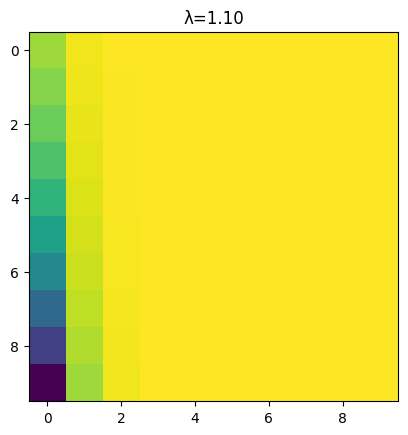

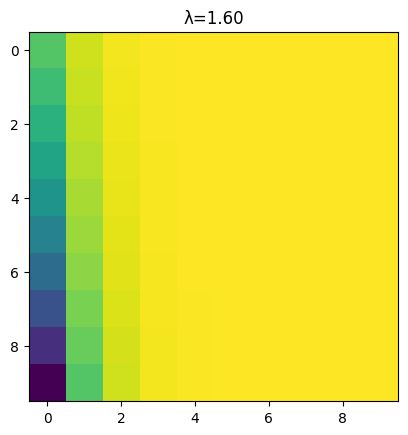

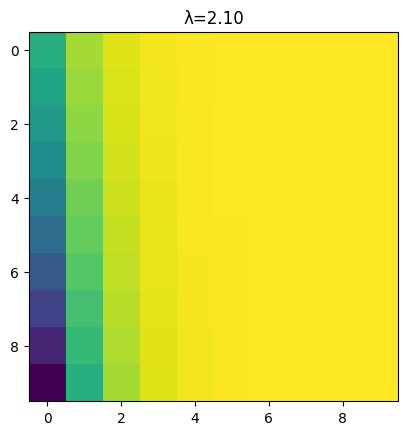

In [22]:
for i in range(5):
    w = np.array([0.9, -0.1]).reshape((1, 2))
    y = sigmoidt_complex_neuron(x=x, w=w, bias=33.9, lymb=0.1+i*0.5)
    y = y.reshape((10, 10))
    plt.imshow((y + 1) / 2)  # Преобразуем [-1,1] → [0,1]
    plt.title(f'λ={0.1+i*0.5:.2f}')
    plt.show()

# Задание 3. Обучение нейрона по Дельта-правилу


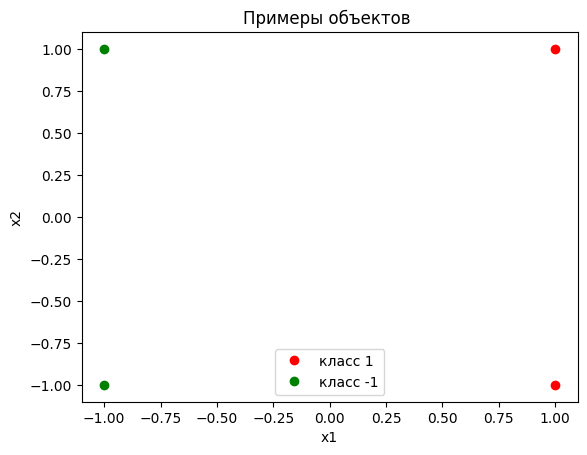

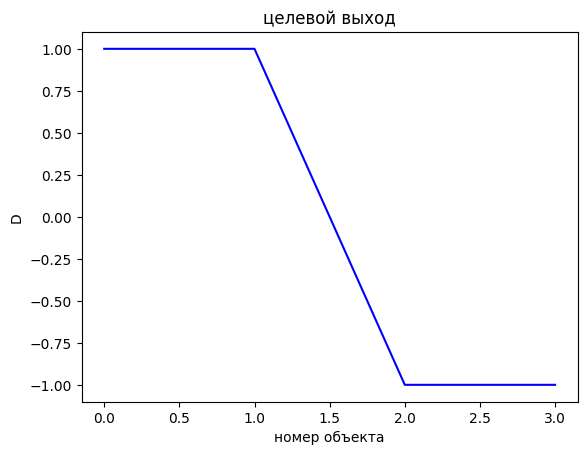

In [23]:
# входное пространство
x1 = np.array([1,1,-1,-1])
x2 = np.array([1,-1,-1,1])
x = np.vstack([x1,x2]).T
D=np.array([1,1,-1,-1]) # целевые значения для входов

# нарисуем
plt.plot(x1[:2],x2[:2], 'or', label = 'класс 1')
plt.plot(x1[2:4],x2[2:4], 'og', label = 'класс -1')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Примеры объектов ')
plt.show()
plt.plot(D, 'b')
plt.title('Примеры значений класса ')
plt.title('целевой выход')
plt.xlabel('номер объекта')
plt.ylabel('D')
plt.show()

Обучение нейрона

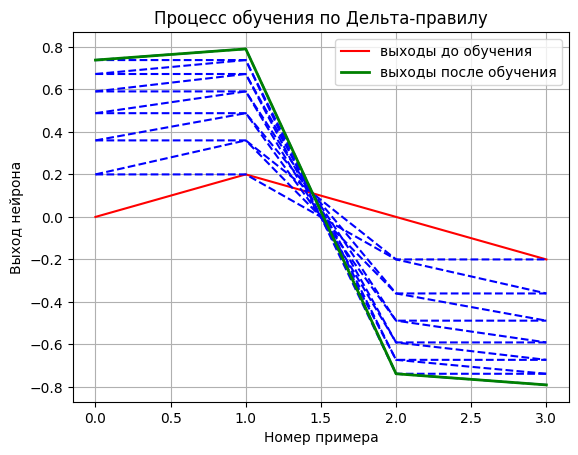

In [24]:
# Начальные веса
w=np.array([0.1,-0.1])
# Вычисляем выход до обучения
#yt = sigmoid_neuron(x = x, w = w, bias = 0)
yt = linear_neuron(x = x, w = w, bias = 0)
plt.plot(yt,'r' , label = 'выходы до обучения')

# Обучение
for k in range(3):                    # 3 эпохи
    for i in range(4):                # 4 примера в каждой эпохе
        e = yt - D                    # Ошибка для всех примеров
        dw = -0.1 * e[i] * x[i, :]    # Коррекция весов для i-го примера
        w = w + dw                    # Обновляем веса
        yt = linear_neuron(x=x, w=w, bias=0)  # Новый выход после обновления
        plt.plot(yt, '--b')           # Рисуем промежуточный выход


# Добавляем подписи для финального графика
plt.plot(yt, 'g', label='выходы после обучения', linewidth=2)
plt.legend()
plt.xlabel('Номер примера')
plt.ylabel('Выход нейрона')
plt.title('Процесс обучения по Дельта-правилу')
plt.grid(True)
plt.show()


# Задание 4. Линейная разделимость


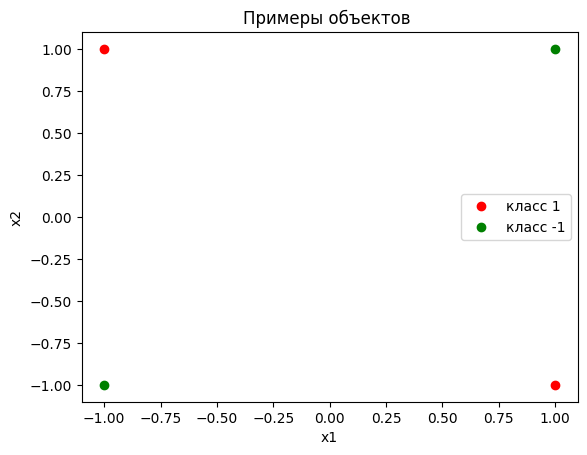

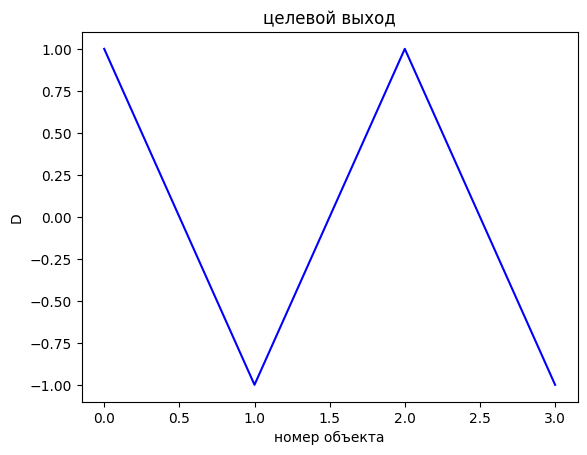

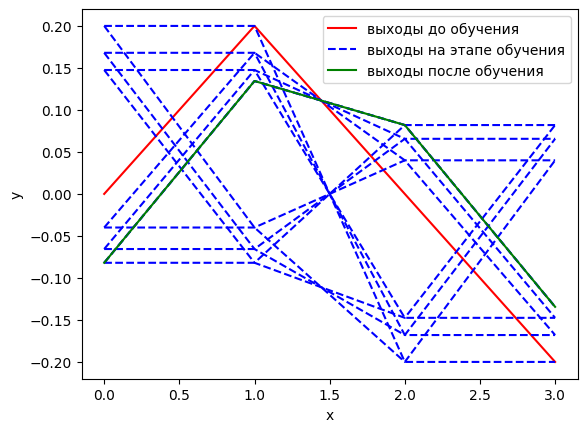

NameError: name 'y_out_22' is not defined

In [27]:
# зададим примеры на вход
x1 = np.array([1,1,-1,-1])
x2 = np.array([1,-1,-1,1])
x = np.vstack([x1,x2]).T
# зададим примеры на выход
D=np.array([1,-1,1,-1])
plt.plot(x1[[1,3]],x2[[1,3]], 'or', label = 'класс 1')
plt.plot(x1[[0,2]],x2[[0,2]],'og', label = 'класс -1')
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Примеры объектов ')
plt.show()
plt.plot(D, 'b')
plt.title('Примеры значений класса ')
plt.title('целевой выход')
plt.xlabel('номер объекта')
plt.ylabel('D')
plt.show()
# Начальные веса
w=np.array([0.1,-0.1])
#yt = sigmoid_neuron(x = x, w = w, bias = 0)
yt = linear_neuron(x = x, w = w, bias = 0)
plt.plot(yt,'r' , label = 'выходы до обучения')

# Обучение
for k in range(3):
  for i in range(4):
    e = yt-D
    dw = - 0.1 * e[i] * x[i,:]
    w = w + dw
    yt = linear_neuron(x = x, w = w, bias = 0)
    plt.plot(yt,'--b')

plt.plot(yt,'--b', label = 'выходы на этапе обучения')
plt.plot(yt,'g', label = 'выходы после обучения')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#Объединим ответы 2-х нейронов в третьем (выходы 2-х первых - входы третьего)
x_y2=np.hstack([y_out_21.reshape((100,1)),y_out_22.reshape((100,1))])
x_y2.shape


#Запустим нейрон и оказывается , что он может объединить решения нейронов , т.е. 1 выставляем
#только там, где оба входных нейрона выставили 1. Остальные области помечены 0.
